# 1. Data Preprocessing

In [1]:
# Import libraries
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import lightgbm as lgb
import joblib
import os
import faiss
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
from lifetimes.utils import calibration_and_holdout_data
from lifetimes import BetaGeoFitter


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Load dataset
df = pd.read_csv('data/online_retail_II.csv')
#save a original dataset to compare after cleaning
original_df =df.copy()

In [2]:
#Standardise column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '')
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

#Removing cancelled transaction
df = df[~df["invoice"].astype("str").str.startswith("C")]

#Drop null customer id
df = df.dropna(subset=['customerid'])

# Check irregular stock code (some contain TEST or POST )
irregular_code = df[df['stockcode'].astype(str).str.count(r'\d') < 4].stockcode.unique()

# Remove irregular stock code
df=df[~df.stockcode.isin(irregular_code)]

#Remove transactions with quantity <1 (returns)
df= df[df.quantity>0]

# Remove transactions with a negative price
df = df[df.price>0]

# Convert all descriptions to upper case
df['description'] = df['description'].str.upper()

# Drop duplicated rows
df = df.drop_duplicates()

In [3]:
# BEFORE VS AFTER CLEANING SUMMARY
comparison = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing CustomerID",
        "Cancelled Transactions",
        "Irregular StockCodes",
        "Quantity <= 0",
        "Price <= 0",
        "Duplicate Rows"
    ],

    "Before Cleaning": [
        original_df.shape[0],
        original_df.shape[1],
        original_df["Customer ID"].isnull().sum() if "Customer ID" in original_df.columns else original_df["Customer ID"].isnull().sum(),
        original_df["Invoice"].astype(str).str.startswith("C").sum() if "Invoice" in original_df.columns else original_df["Invoice"].astype(str).str.startswith("C").sum(),
        original_df[original_df["StockCode"].astype(str).str.count(r"\d") < 4].shape[0] if "StockCode" in original_df.columns else raw_df[raw_df["StockCode"].astype(str).str.count(r"\d") < 4].shape[0],
        (original_df["Quantity"] <= 0).sum() if "Quantity" in original_df.columns else (original_df["Quantity"] <= 0).sum(),
        (original_df["Price"] <= 0).sum() if "Price" in original_df.columns else (original_df["Price"] <= 0).sum(),
        original_df.duplicated().sum()
    ],

    "After Cleaning": [
        df.shape[0],
        df.shape[1],
        df["customerid"].isnull().sum(),
        df["invoice"].astype(str).str.startswith("C").sum(),
        df[df["stockcode"].astype(str).str.count(r"\d") < 4].shape[0],
        (df["quantity"] <= 0).sum(),
        (df["price"] <= 0).sum(),
        df.duplicated().sum()
    ]
})

comparison

,Metric,Before Cleaning,After Cleaning
0,Rows,1067371,776579
1,Columns,8,8
2,Missing CustomerID,243007,0
3,Cancelled Transactions,19494,0
4,Irregular StockCodes,5882,0
5,Quantity <= 0,22950,0
6,Price <= 0,6207,0
7,Duplicate Rows,34335,0


### Data Cleaning Summary

The raw Online Retail II dataset originally contained 1,067,371 transaction records. Several preprocessing steps were applied to improve data quality before modelling.

The cleaning process included:
- removing transactions with missing CustomerID
- removing cancelled invoices
- removing irregular stock codes
- removing return transactions with non-positive quantity
- removing transactions with non-positive prices
- removing duplicated records

After preprocessing, the final cleaned dataset contained 776,579 valid customer-product purchase interactions suitable for churn prediction, retrieval modelling, and recommendation ranking.

# 2. Churn Label Construction & Features Engineering

Since the Online Retail II dataset does not contain an explicit churn label, churn was defined based on future purchasing behaviour.

A customer is labelled as churned if they do not make any purchase within the next 90 days after the cutoff date.

- `churn = 1`: customer did not return within the next 90 days
- `churn = 0`: customer returned within the next 90 days

In [4]:
# Ensure datetime format and sort for proper chronological order

df = df.sort_values(['customerid', 'invoicedate'])

N = 90  # churn window (days)

# Cutoff date: last date minus N days
T = df['invoicedate'].max() - pd.Timedelta(days=N)

# Split data
train = df[df['invoicedate'] <= T]   # past data (for features)
future = df[df['invoicedate'] > T]   # next N days (for churn label)

# Build churn dataset
churn_labels = (
    # Last purchase per customer in training window
    train.groupby('customerid')['invoicedate']
         .max()
         .rename('last_purchase_date')
         .reset_index()
    # Add first return date in future window (if any)
    .merge(
        future.groupby('customerid')['invoicedate']
              .min()
              .rename('return_date'),
        on='customerid', how='left'
    )
)

# Churn label: 1 = did NOT return within N days, 0 = returned
churn_labels['churn'] = churn_labels['return_date'].isna().astype(int)

In [5]:
#Total eligible customers (customers have at least 1 transaction in training window)
churn_labels['customerid'].nunique()

5256

In [6]:
#Final user-level dataset
churn_labels.groupby('churn').count()

,customerid,last_purchase_date,return_date
churn,,,
0,2289,2289,2289
1,2967,2967,0


## Feature engineering

Customer-level features were engineered from historical transaction data to support churn prediction modelling.

The feature set includes traditional RFM features:
- Frequency
- Monetary value
- Recency

Additional behavioural features were also generated to better capture customer purchasing behaviour, including:
- product diversity
- average purchasing interval
- purchasing interval variability
- last purchasing interval
- average basket size
- maximum basket size
- minimum basket size

All features were generated using only historical transactions before the cutoff date to avoid information leakage from future purchase behaviour.

The final churn modelling dataset contains both customer behavioural features and the churn label generated from the future 90-day observation window.

In [7]:
def build_features(transaction_df, cutoff_date, label_window_days=90):
    """
    Build features using only transactions <= cutoff_date.
    Label churn = 1 if NO transaction in (cutoff_date, cutoff_date + label_window_days].
    Returns a DataFrame indexed by customer_id with engineered features and 'churn' column.
    """
    # limit transactions to data available at cutoff
    tx_cut = transaction_df[transaction_df['invoicedate'] <= cutoff_date].copy()
    cutoff_date = pd.to_datetime(cutoff_date)

    # base churn_df from available data (up to cutoff)
    ## features calculation
    # create a new column for total amount paid per stockcode per invoice
    tx_cut['total_paid']=tx_cut['quantity']*tx_cut['price']
    
    churn_df_cut = tx_cut.groupby('customerid').agg(
        last_transaction=('invoicedate', 'max'),
        frequency=('invoice', 'nunique'),
        monetary=('total_paid', 'sum'),
        product_diversity = ('stockcode','nunique'),
    ).reset_index()
    churn_df_cut['recency'] = (cutoff_date - churn_df_cut['last_transaction']).dt.days
    
    # basket size
    basket_size_df = tx_cut.groupby(['customerid','invoice']).total_paid.sum().reset_index()
    basket_size_calculation = basket_size_df.groupby('customerid').agg(
        avg_basket_size = ('total_paid','mean'),
        max_basket_size = ('total_paid','max'),
        min_basket_size = ('total_paid','min'),
    ) .reset_index()
    
    # purchasing interval at invoice-level
    purchase_dates = ( tx_cut.groupby(['customerid', 'invoice'])['invoicedate'].min().reset_index()
                    .sort_values(['customerid', 'invoicedate']) )
    
    # days between consecutive purchases/invoices
    purchase_dates['diff_days'] = (purchase_dates.groupby('customerid')['invoicedate'].diff().dt.days )
    
    # aggregate interval features per customer
    purchasing_interval = (
        purchase_dates.groupby('customerid')['diff_days']
        .agg(
            avg_purchasing_interval='mean',
            std_purchasing_interval='std',
            last_purchasing_interval='last'
        ).reset_index()   )
    
    # Compute churn label using transactions AFTER cutoff within the label window
    future_start = cutoff_date
    future_end = cutoff_date + pd.Timedelta(days=label_window_days)
    future_tx = transaction_df[(transaction_df['invoicedate'] > future_start) &
                             (transaction_df['invoicedate'] <= future_end)]
    future_user = future_tx['customerid']
    churn_df_cut['churn'] = (~churn_df_cut['customerid'].isin(future_user) ).astype(int)

    # merge all features
    features_df = churn_df_cut.merge(purchasing_interval, on ='customerid', how ='left')\
                               .merge(basket_size_calculation, on ='customerid', how ='left')
    
    #fill missing values of customers with only 1 transaction
    features_df = features_df.fillna({
            'avg_purchasing_interval': 999,
            'std_purchasing_interval': 0,
            'last_purchasing_interval': 999
            }).drop(columns='last_transaction')
    return features_df

In [8]:
cutoff_train = df['invoicedate'].max() - pd.Timedelta(days=270)
cutoff_test  = df['invoicedate'].max() - pd.Timedelta(days=90)

# Build features using only data up to each cutoff
train_df= build_features(df, cutoff_train, label_window_days=90)
test_df  = build_features(df, cutoff_test, label_window_days=90)

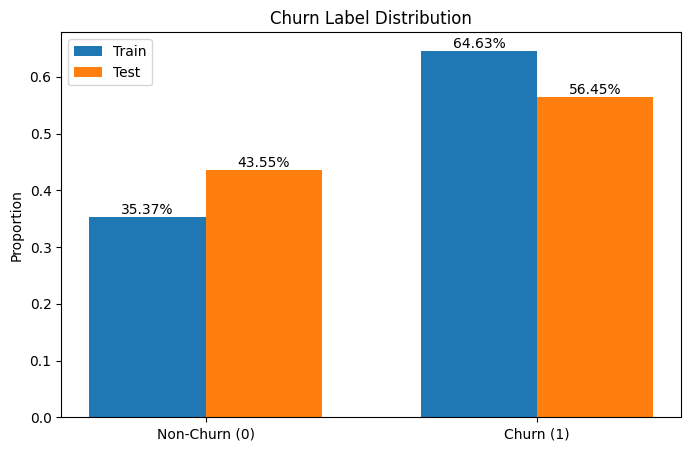

In [9]:
# CHURN LABEL DISTRIBUTION

train_dist = (
    train_df["churn"]
    .value_counts(normalize=True)
    .sort_index()
)

test_dist = (
    test_df["churn"]
    .value_counts(normalize=True)
    .sort_index()
)

labels = ["Non-Churn (0)", "Churn (1)"]

x = range(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

# Train bars
train_bars = plt.bar(
    [i - width/2 for i in x],
    train_dist.values,
    width=width,
    label="Train"
)

# Test bars
test_bars = plt.bar(
    [i + width/2 for i in x],
    test_dist.values,
    width=width,
    label="Test"
)

# Add value labels
for bar in train_bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2%}",
        ha='center',
        va='bottom'
    )

for bar in test_bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2%}",
        ha='center',
        va='bottom'
    )

plt.xticks(x, labels)

plt.ylabel("Proportion")
plt.title("Churn Label Distribution")

plt.legend()

plt.show()

### Churn Label Distribution

The churn dataset exhibited a moderate class imbalance, with churn customers representing 64.6% of the dataset and non-churn customers representing 35.4%.

Since the distribution was not severely skewed, no resampling technique was applied during model training. Tree-based models such as LightGBM are generally robust to moderate class imbalance and can effectively handle imbalanced distributions through internal weighting mechanisms.

# 3. Churn Prediction Models

Two complementary churn-related models were implemented in this project:

*LightGBM Churn Classification*

A LightGBM classifier was used to predict customer churn probability based on behavioural and transactional features.

LightGBM was selected because:
- it performs well on structured tabular data
- it can capture non-linear customer behaviour patterns
- it handles moderate class imbalance effectively
- it provides fast training and strong predictive performance

The model outputs a churn probability score for each customer that can be used for Recommender System.

---

*BG/NBD Model*

The BG/NBD model was used to estimate:
- customer probability of being active (`p_alive`)
- expected future purchases

Unlike supervised classification models, BG/NBD models customer purchasing behaviour probabilistically using transaction frequency and recency patterns.

The BG/NBD outputs were later integrated into the recommendation ranking pipeline as customer behavioural signals.

## 3.1 LightGBM
### 3.1.1 Training & Predict

In [10]:
# Prepare data
X_train = train_df.drop(columns=['churn', 'customerid'])
y_train = train_df['churn']
X_test = test_df.drop(columns=['churn', 'customerid'])
y_test = test_df['churn']

# Model
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    force_col_wise=True
)

# Train
lgb_model.fit(X_train, y_train)
# Predict
churn_proba = lgb_model.predict_proba(X_test)[:, 1]

[LightGBM] [Info] Number of positive: 2964, number of negative: 1622
[LightGBM] [Info] Total Bins 2335
[LightGBM] [Info] Number of data points in the train set: 4586, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.646315 -> initscore=0.602880
[LightGBM] [Info] Start training from score 0.602880


### 3.1.2 Evaluation

In [11]:
print("AUC:", roc_auc_score(y_test, churn_proba))
print(classification_report(y_test, (churn_proba > 0.5).astype(int)))

AUC: 0.7664992064301904
              precision    recall  f1-score   support

           0       0.78      0.45      0.57      2289
           1       0.68      0.90      0.78      2967

    accuracy                           0.71      5256
   macro avg       0.73      0.68      0.67      5256
weighted avg       0.72      0.71      0.69      5256



The LightGBM churn classifier achieved an AUC-ROC score of 0.77, indicating good discriminative performance between churn and non-churn customers.

The model achieved strong recall for churn customers (0.90), meaning that most high-risk customers were successfully identified. Although precision was moderate (0.68), this trade-off is acceptable in churn prediction tasks where missing churn customers is typically more costly than generating additional retention actions.

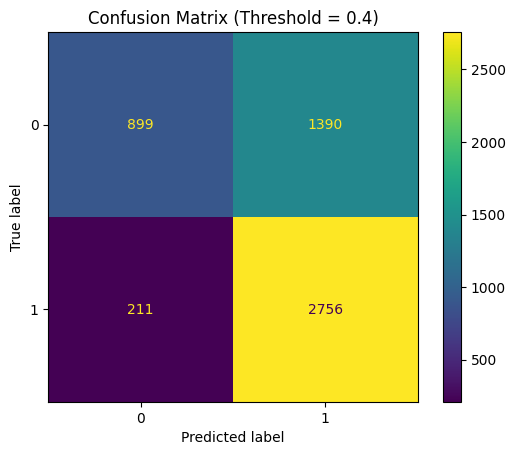

In [12]:
# A classification threshold of 0.4 was selected to prioritise churn customer detection 
#and improve recall performance for high-risk customers.

y_pred = (churn_proba > 0.4).astype(int)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (Threshold = 0.4)")
plt.show()

The confusion matrix shows that the model successfully identified most churn customers, with 2,756 correctly classified churn cases and only 211 false negatives.

A lower classification threshold of 0.4 was used to prioritise churn detection and maximise recall for high-risk customers. Although this increased the number of false positives, the trade-off is acceptable for customer retention scenarios where missing churn customers is more costly than applying additional retention actions.

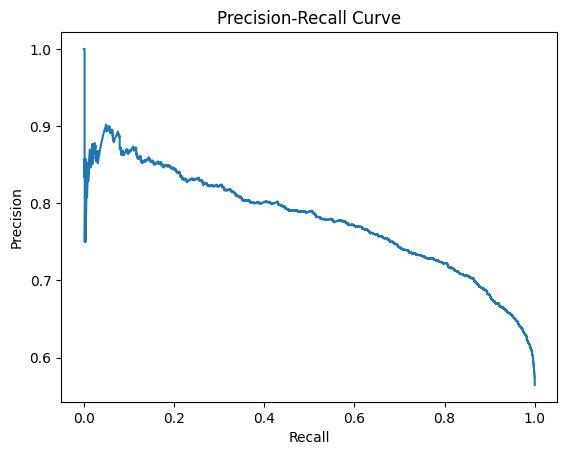

In [13]:
precision, recall, _ = precision_recall_curve(y_test, churn_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

The Precision-Recall curve demonstrates stable predictive performance across different recall levels.

The model maintains relatively strong precision while achieving high recall, indicating that it can successfully identify a large proportion of churn customers without excessively increasing false positive predictions. This behaviour is suitable for retention-focused business scenarios where detecting at-risk customers is a key priority.

### 3.1.3 Save model

In [14]:
joblib.dump( lgb_model, "models/churn/lightgbm_churn.pkl")

['models/churn/lightgbm_churn.pkl']

### 3.4 Generate Churn Probability for Recommendation System

In [15]:
#build inference data
latest_cutoff = df['invoicedate'].max()  - pd.Timedelta(days=90)
lgb_inference = build_features(df, cutoff_date=latest_cutoff, label_window_days=90 ).drop(columns='churn')
X_inf = lgb_inference.drop(columns=['customerid'])

#Apply LightGBM model to predict final churn probability
lgb_inference['churn_prob'] = (lgb_model.predict_proba(X_inf)[:,1])
lgb_inference

,customerid,frequency,monetary,product_diversity,recency,avg_purchasing_interval,std_purchasing_interval,last_purchasing_interval,avg_basket_size,max_basket_size,min_basket_size,churn_prob
0,12346.0,3,77352.96,25,235,160.5,60.104076,203.0,25784.320000,77183.60,27.05,0.976683
1,12347.0,6,3402.39,107,39,54.4,12.759310,53.0,567.065000,711.79,382.52,0.158925
2,12348.0,4,1388.40,24,158,63.0,21.377558,70.0,347.100000,652.80,187.44,0.755459
3,12349.0,2,2221.14,89,317,181.0,0.000000,181.0,1110.570000,1152.62,1068.52,0.986677
4,12350.0,1,294.40,16,219,999.0,0.000000,999.0,294.400000,294.40,294.40,0.570409
...,...,...,...,...,...,...,...,...,...,...,...,...
5251,18283.0,16,1700.25,284,5,37.0,38.217423,52.0,106.265625,192.80,2.50,0.361328
5252,18284.0,1,411.68,27,341,999.0,0.000000,999.0,411.680000,411.68,411.68,0.989189
5253,18285.0,1,377.00,11,570,999.0,0.000000,999.0,377.000000,377.00,377.00,0.993865
5254,18286.0,2,1246.43,66,386,247.0,0.000000,247.0,623.215000,833.48,412.95,0.982242


## 3.2 BG-NBD model
### 3.2.1 Training

In [16]:
#Train BG-NBD model using calibration and holdout data
def bgnbd_feature_engineering(df):
    from lifetimes.utils import calibration_and_holdout_data
    
    obs_date = df.invoicedate.max()
    cal_date= df.invoicedate.max() - pd.Timedelta(days=90)
    summary = df.groupby(['customerid','invoice','invoicedate']).sum().reset_index()
    
    # build calibration and holdout dataset
    calibration_holdout = calibration_and_holdout_data(
        transactions=summary,
        customer_id_col='customerid',
        datetime_col='invoicedate',
        calibration_period_end=cal_date,  
        observation_period_end=obs_date,  
        freq='D' 
    ).reset_index()
    return calibration_holdout
#final data
calibration_holdout = bgnbd_feature_engineering(df)
calibration_holdout.head(5)

,customerid,frequency_cal,recency_cal,T_cal,frequency_holdout,duration_holdout
0,12346.0,2.0,322.0,557.0,0.0,90.0
1,12347.0,5.0,275.0,314.0,2.0,90.0
2,12348.0,3.0,190.0,348.0,1.0,90.0
3,12349.0,1.0,182.0,499.0,1.0,90.0
4,12350.0,0.0,0.0,220.0,0.0,90.0


In [17]:
#Fit model
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(
    calibration_holdout['frequency_cal'],
    calibration_holdout['recency_cal'],
    calibration_holdout['T_cal']
)
# Predict
t = calibration_holdout['duration_holdout'].max()

calibration_holdout['p_alive'] = bgf.conditional_probability_alive(
    calibration_holdout['frequency_cal'],
    calibration_holdout['recency_cal'],
    calibration_holdout['T_cal'])

calibration_holdout['pred_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    t,
    calibration_holdout['frequency_cal'],
    calibration_holdout['recency_cal'],
    calibration_holdout['T_cal']
)

### 3.2.3 Evaluation

In [18]:
# Evaluate model using MAE, RMSE, Correlation between predicted and actual purchase behavior
y_true = calibration_holdout['frequency_holdout']
y_pred = calibration_holdout['pred_purchases']
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("MAE:", mae)
print("RMSE:", rmse)
corr = np.corrcoef(y_true, y_pred)[0, 1]
print("Correlation:", corr)

MAE: 0.6950274025136859
RMSE: 1.2035553365189577
Correlation: 0.8094283165094652


The BG/NBD model achieved a strong correlation score of 0.81 between predicted and actual future purchases, indicating that the model effectively captures customer purchasing behaviour patterns.

The MAE and RMSE values suggest reasonable prediction accuracy for expected transaction frequency, particularly given the stochastic nature of customer purchase behaviour in retail transaction data.

Overall, the BG/NBD model provides useful behavioural signals such as `p_alive` and expected future purchases, which were later incorporated into the recommendation ranking pipeline.

### 3.2.4 Save model

In [19]:
os.makedirs("models/churn", exist_ok=True)

bgf.save_model(
    "models/churn/bgnbd_model.pkl"
)

# 4. Retrieval Model (ALS + FAISS)

### 4.1 Build Historical Interaction Data

In [20]:
df["interaction"] = np.log1p(df["quantity"]) * np.log1p(df["price"])
cutoff = df["invoicedate"].max() - pd.Timedelta(days=90)

als_train_df = df[df["invoicedate"] <= cutoff].copy()
als_test_df  = df[df["invoicedate"] > cutoff].copy()

### 4.1 Training model

In [21]:
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares

def train_als_pipeline(
    data,
    user_col="customerid",
    item_col="stockcode",
    interaction_col="interaction",
    factors=64,
    regularization=0.01,
    iterations=20,
    random_state=42
):
    """
    Train ALS model and return everything needed
    for retrieval / FAISS / recommendation.
    """

    # copy
    df = data.copy()

    # create mappings
    user_ids = df[user_col].unique()
    item_ids = df[item_col].unique()

    user_map = {u: i for i, u in enumerate(user_ids)}
    item_map = {i: j for j, i in enumerate(item_ids)}

    idx_to_user = {v: k for k, v in user_map.items()}
    idx_to_item = {v: k for k, v in item_map.items()}

    # map indices
    df["user_idx"] = df[user_col].map(user_map)
    df["item_idx"] = df[item_col].map(item_map)

    # build user-item matrix
    user_item_matrix = csr_matrix(
        (
            df[interaction_col],
            (df["user_idx"], df["item_idx"])
        ),
        shape=(len(user_map), len(item_map))
    )

    # train ALS
    model = AlternatingLeastSquares(
        factors=factors,
        regularization=regularization,
        iterations=iterations,
        random_state=random_state
    )
    
    model.fit(user_item_matrix)

    # embeddings
    user_embeddings = model.user_factors
    item_embeddings = model.item_factors

    # purchased items
    user_bought_items = (
        df.groupby(user_col)[item_col]
        .apply(set)
        .to_dict()
    )

    # recommendation function
    def recommend(user_id, N=50):

        if user_id not in user_map:
            return pd.DataFrame()

        user_idx = user_map[user_id]

        item_indices, scores = model.recommend(
            userid=user_idx,
            user_items=user_item_matrix[user_idx],
            N=N,
            filter_already_liked_items=False
        )

        return pd.DataFrame({
            user_col: user_id,
            item_col: [idx_to_item[i] for i in item_indices],
            "als_score": scores
        })

    return {
        "model": model,
        "matrix": user_item_matrix,

        "user_map": user_map,
        "item_map": item_map,

        "idx_to_user": idx_to_user,
        "idx_to_item": idx_to_item,

        "user_embeddings": user_embeddings,
        "item_embeddings": item_embeddings,

        "recommend_fn": recommend,
        "user_bought_items": user_bought_items
    }

als_eval = train_als_pipeline(als_train_df)

C:\Users\anhd\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\anhd\AppData\Roaming\Python\Python313\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 51.11it/s]


### 4.3 Prepare Ground Truth for ALS Evaluation

Future purchases in the last 90 days were used as ground truth to evaluate whether ALS recommendations could recover items customers later purchased.

In [22]:
eval_user_map = als_eval["user_map"]
eval_item_map = als_eval["item_map"]

als_test_eval = als_test_df[
    als_test_df["customerid"].isin(eval_user_map) &
    als_test_df["stockcode"].isin(eval_item_map)
].copy()

ground_truth = (
    als_test_eval.groupby("customerid")["stockcode"]
    .apply(set)
    .to_dict()
)

### 4.4 Evaluation
The ALS retrieval model was evaluated using Recall@K and NDCG@K. This measures the quality of the candidate generation stage before the ranking model.

In [23]:
def recall_at_k(actual, predicted, k=10):
    actual = set(actual)
    predicted = predicted[:k]

    if len(actual) == 0:
        return np.nan

    return len(actual & set(predicted)) / len(actual)


def ndcg_at_k(actual, predicted, k=10):
    actual = set(actual)
    predicted = predicted[:k]

    dcg = 0.0

    for i, item in enumerate(predicted):
        if item in actual:
            dcg += 1 / np.log2(i + 2)

    ideal_hits = min(len(actual), k)

    if ideal_hits == 0:
        return np.nan

    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))

    return dcg / idcg
def evaluate_als(als_obj, ground_truth, k=10):
    recall_scores = []
    ndcg_scores = []

    recommend_fn = als_obj["recommend_fn"]

    for user_id, actual_items in ground_truth.items():
        pred_df = recommend_fn(user_id, N=k)
        predicted_items = pred_df["stockcode"].tolist()

        recall_scores.append(recall_at_k(actual_items, predicted_items, k))
        ndcg_scores.append(ndcg_at_k(actual_items, predicted_items, k))

    return {
        f"Recall@{k}": np.nanmean(recall_scores),
        f"NDCG@{k}": np.nanmean(ndcg_scores)
    }

print(evaluate_als(als_eval, ground_truth, k=10))
print(evaluate_als(als_eval, ground_truth, k=50))
print(evaluate_als(als_eval, ground_truth, k=100))

{'Recall@10': np.float64(0.11104851096538979), 'NDCG@10': np.float64(0.2674495511782689)}
{'Recall@50': np.float64(0.2690018186312551), 'NDCG@50': np.float64(0.2702682122292832)}
{'Recall@100': np.float64(0.3545381051796986), 'NDCG@100': np.float64(0.2977116216299317)}


The ALS retrieval model achieved Recall@10 of 0.111 and NDCG@10 of 0.267, meaning that around 11.1% of future purchased items were recovered within the top 10 recommendations.

Recall increased to 0.269 at K=50 and 0.355 at K=100, showing that a larger candidate pool improves coverage. This supports the use of ALS as a candidate generation model before applying the Wide & Deep ranking stage.

### 4.5 Extract ALS Embeddings for FAISS

In [24]:
user_embeddings = als_eval["user_embeddings"]
item_embeddings = als_eval["item_embeddings"]

user_map = als_eval["user_map"]
item_map = als_eval["item_map"]
idx_to_item = als_eval["idx_to_item"]

### 4.6 Build FAISS Index
FAISS was used to index ALS item embeddings for efficient approximate nearest neighbour retrieval.

In [25]:
item_matrix = item_embeddings.astype("float32")

# cosine similarity
faiss.normalize_L2(item_matrix)

index = faiss.IndexFlatIP(item_matrix.shape[1])
index.add(item_matrix)

print("FAISS index size:", index.ntotal)

FAISS index size: 4444


### 4.7 Generate FAISS Candidate Items

In [26]:
def faiss_retrieve_candidates(user_id, top_n=100, buffer_n=200):
    if user_id not in user_map:
        return pd.DataFrame()

    user_idx = user_map[user_id]

    user_vector = user_embeddings[user_idx].reshape(1, -1).astype("float32")
    faiss.normalize_L2(user_vector)

    scores, item_indices = index.search(user_vector, buffer_n)

    results = []

    for item_idx, score in zip(item_indices[0], scores[0]):
        stockcode = idx_to_item[item_idx]

        results.append({
            "customerid": user_id,
            "stockcode": stockcode,
            "faiss_score": float(score)
        })

        if len(results) >= top_n:
            break

    return pd.DataFrame(results)

In [27]:
all_candidates = []

for user_id in user_map.keys():
    temp = faiss_retrieve_candidates(user_id, top_n=100)
    all_candidates.append(temp)

candidate_df = pd.concat(all_candidates, ignore_index=True)

candidate_df.head()

,customerid,stockcode,faiss_score
0,12346.0,21523,0.737072
1,12346.0,48187,0.726129
2,12346.0,22692,0.712484
3,12346.0,22366,0.699142
4,12346.0,48184,0.697919


### 4.8 Save Retrieval Outputs

In [28]:
os.makedirs("models/retrieval", exist_ok=True)

als_artifacts = {
    "model": als_eval["model"],
    "matrix": als_eval["matrix"],
    "user_map": als_eval["user_map"],
    "item_map": als_eval["item_map"],
    "idx_to_user": als_eval["idx_to_user"],
    "idx_to_item": als_eval["idx_to_item"],
    "user_embeddings": als_eval["user_embeddings"],
    "item_embeddings": als_eval["item_embeddings"]
}

with open(
    "models/retrieval/als_artifacts.pkl",
    "wb"
) as f:
    pickle.dump(als_artifacts, f)

print("ALS artifacts saved.")

os.makedirs("faiss", exist_ok=True)

faiss.write_index(
    index,
    "faiss/faiss_index.index"
)

print("FAISS index saved.")

candidate_df.to_csv("data/retrieval_candidates.csv",index=False)

ALS artifacts saved.
FAISS index saved.


## 5. Ranking Model (Wide & Deep)

The Wide & Deep architecture was selected because it can combine collaborative filtering representations with customer behavioural features in a single ranking model.

The deep component learns latent user-item interaction patterns through embeddings, while the wide component incorporates explicit churn-aware numerical features such as churn probability, purchase activity, and retrieval scores.

### 5.1 Ranking Dataset Construction

The ranking dataset was created by combining retrieval candidates with customer behavioural features and churn-related signals.

Each user-item pair contains:
- ALS / FAISS retrieval score
- churn probability
- BG/NBD behavioural features
- future interaction label

The ranking label indicates whether the customer purchased the product in the future observation window.

In [29]:
# Define train/test window
max_date = df['invoicedate'].max()
rec_cutoff = max_date - pd.Timedelta(days=90)

df_hist = df[df['invoicedate'] <= rec_cutoff].copy()
df_future = df[df['invoicedate'] > rec_cutoff].copy()

user_col = 'customerid'
item_col = 'stockcode'

# Ground truth future items
future_items = (
    df_future
    .groupby(user_col)[item_col]
    .apply(set)
    .to_dict()
)

# Historical purchased items for filtering old items
hist_items = (
    df_hist
    .groupby(user_col)[item_col]
    .apply(set)
    .to_dict()
)

In [30]:
#add label column
candidate_df['label'] = candidate_df.apply(
    lambda row: int(
        row[item_col] in future_items.get(row[user_col], set())
    ),
    axis=1 )

ranking_df = candidate_df.merge(lgb_inference[[user_col, 'churn_prob']], on=user_col, how='left')\
                        .merge(calibration_holdout[[user_col, 'pred_purchases','p_alive']], on=user_col, how='left' )

ranking_df['has_bought_before'] = ranking_df.apply(
 lambda row: int(row[item_col] in hist_items.get(row[user_col], set())), axis=1)

# user activity from historical data
user_features = df_hist.groupby(user_col).agg(
    user_purchase_count=(item_col, "count"),
    user_unique_items=(item_col, "nunique")
).reset_index()

# item popularity from historical data
item_features = df_hist.groupby(item_col).agg(
    item_popularity=(user_col, "nunique")
).reset_index()

ranking_df = ranking_df.merge(user_features, on=user_col, how="left")
ranking_df = ranking_df.merge(item_features, on=item_col, how="left")

ranking_df = ranking_df.fillna(0)

#Copy data for later evaluation
ranking_df_raw = ranking_df.copy()

In [31]:
ranking_df_raw

,customerid,stockcode,faiss_score,label,churn_prob,pred_purchases,p_alive,has_bought_before,user_purchase_count,user_unique_items,item_popularity
0,12346.0,21523,0.737072,0,0.976683,0.325178,0.855034,1,25,25,315
1,12346.0,48187,0.726129,0,0.976683,0.325178,0.855034,1,25,25,468
2,12346.0,22692,0.712484,0,0.976683,0.325178,0.855034,1,25,25,247
3,12346.0,22366,0.699142,0,0.976683,0.325178,0.855034,1,25,25,233
4,12346.0,48184,0.697919,0,0.976683,0.325178,0.855034,0,25,25,343
...,...,...,...,...,...,...,...,...,...,...,...
525595,18287.0,22233,0.288423,0,0.309703,0.553650,0.927744,0,113,92,93
525596,18287.0,20814,0.287462,0,0.309703,0.553650,0.927744,0,113,92,7
525597,18287.0,72529W,0.286608,0,0.309703,0.553650,0.927744,0,113,92,39
525598,18287.0,22245,0.285854,0,0.309703,0.553650,0.927744,0,113,92,166


### 5.2 Feature Encoding, Train/Test Split and Scaling

In [32]:
# Encoding
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

ranking_df["user_idx"] = user_encoder.fit_transform(ranking_df[user_col].astype(str))
ranking_df["item_idx"] = item_encoder.fit_transform(ranking_df[item_col].astype(str))

In [33]:
#Train test split by user id (not randomly)
users = ranking_df["customerid"].unique()

train_users, test_users = train_test_split(
    users,
    test_size=0.2,
    random_state=42
)

ranking_train_df = ranking_df[
    ranking_df["customerid"].isin(train_users)
].copy()

ranking_test_df = ranking_df[
    ranking_df["customerid"].isin(test_users)
].copy()

In [34]:
# Scaling
num_features = [
    "faiss_score",
    "churn_prob",
    "pred_purchases",
    "p_alive",
    "has_bought_before",
    "user_purchase_count",
    "user_unique_items",
    "item_popularity"
]

scaler = StandardScaler()

ranking_train_df[num_features] = scaler.fit_transform(
    ranking_train_df[num_features]
)

ranking_test_df[num_features] = scaler.transform(
    ranking_test_df[num_features]
)

### 5.3 Convert Data to PyTorch Tensors

In [35]:
# TRAIN TENSORS
X_user_train = torch.tensor(
    ranking_train_df["user_idx"].values,
    dtype=torch.long
)

X_item_train = torch.tensor(
    ranking_train_df["item_idx"].values,
    dtype=torch.long
)

X_num_train = torch.tensor(
    ranking_train_df[num_features].values,
    dtype=torch.float32
)

y_train = torch.tensor(
    ranking_train_df["label"].values,
    dtype=torch.float32
)

# TEST TENSORS
X_user_test = torch.tensor(
    ranking_test_df["user_idx"].values,
    dtype=torch.long
)

X_item_test = torch.tensor(
    ranking_test_df["item_idx"].values,
    dtype=torch.long
)

X_num_test = torch.tensor(
    ranking_test_df[num_features].values,
    dtype=torch.float32
)

y_test = torch.tensor(
    ranking_test_df["label"].values,
    dtype=torch.float32
)

### 5.4 Wide & Deep Model Architecture
A Wide & Deep neural ranking model was implemented to combine:
- latent user-item embeddings
- numerical behavioural features

The embedding layers capture collaborative preference patterns, while dense numerical features incorporate churn-aware behavioural signals.

In [36]:
#define a simple wide and deep model
class SimpleWideDeep(nn.Module):
    def __init__(self, n_users, n_items, n_features, emb_dim=16):
        super().__init__()

        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)

        self.model = nn.Sequential(
            nn.Linear(emb_dim * 2 + n_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) )

    def forward(self, user, item, num):
        user_vec = self.user_emb(user)
        item_vec = self.item_emb(item)

        x = torch.cat([user_vec, item_vec, num], dim=1)
        return self.model(x).squeeze()

### 5.5 Ranking Model Training

In [37]:
# TRAIN MODEL

# Number of unique users and items
n_users = ranking_df["user_idx"].max() + 1
n_items = ranking_df["item_idx"].max() + 1
n_features = len(num_features)

model = SimpleWideDeep(n_users, n_items, n_features)

# Number of numerical input features
n_features = len(num_features)

# Initialize Wide & Deep model
model = SimpleWideDeep(
    n_users,
    n_items,
    n_features
)
# Handle class imbalance
# Positive labels are much fewer than negatives,so use weighted BCE loss.

pos_weight = (
    (ranking_train_df["label"] == 0).sum()
    /
    (ranking_train_df["label"] == 1).sum()
)

loss_fn = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        pos_weight,
        dtype=torch.float32
    )
)

# Adam optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [38]:
# TRAINING LOOP
# Number of full training passes through the dataset
epochs = 10

# Number of samples processed before updating weights
batch_size = 1024

for epoch in range(epochs):

    # Shuffle training samples each epoch
    permutation = torch.randperm(len(y_train))

    total_loss = 0

    # Process training data in mini-batches
    for i in range(0, len(y_train), batch_size):

        # Get batch indices
        idx = permutation[i:i+batch_size]
        # Create batch tensors
        batch_user = X_user_train[idx]
        batch_item = X_item_train[idx]
        batch_num = X_num_train[idx]
        batch_y = y_train[idx]

        # Clear gradients from previous step
        optimizer.zero_grad()

        # Forward pass
        # Predict ranking scores
        logits = model(
            batch_user,
            batch_item,
            batch_num
        )
        # Compute ranking loss
        loss = loss_fn(
            logits,
            batch_y
        )

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        total_loss += loss.item()

    # Print training loss after each epoch
    print(
        f"Epoch {epoch+1}, "
        f"Loss: {total_loss:.4f}"
    )

Epoch 1, Loss: 385.1278
Epoch 2, Loss: 327.9082
Epoch 3, Loss: 278.1369
Epoch 4, Loss: 240.1885
Epoch 5, Loss: 217.0550
Epoch 6, Loss: 201.6999
Epoch 7, Loss: 190.6177
Epoch 8, Loss: 182.2827
Epoch 9, Loss: 175.2734
Epoch 10, Loss: 169.3736


### 5.6 Evaluation

In [39]:
# Switch model to evaluation mode
model.eval()

# Disable gradient calculation during inference
# This speeds up prediction and reduces memory usage
with torch.no_grad():

    # Generate ranking scores for test data only
    logits = model(
        X_user_test,
        X_item_test,
        X_num_test
    )

    # Convert logits into probabilities between 0 and 1
    # Higher score = higher recommendation relevance
    ranking_test_df["ranking_score"] = (
        torch.sigmoid(logits).numpy()
    )

In [40]:
def evaluate_recommender(df, k=10):
    recall_scores = []
    ndcg_scores = []
    # Evaluate recommendations for each user
    for _, group in df.groupby("customerid"):
        # Sort items by predicted ranking score
        group = group.sort_values(
            "ranking_score",
            ascending=False)

        # Get true labels
        labels = group["label"].values

        # Top-K predicted items
        top_k_labels = labels[:k]

        # Total relevant items in future window
        total_relevant = labels.sum()
        if total_relevant == 0:
            continue

        # Recall@K
        recall = top_k_labels.sum() / total_relevant
        recall_scores.append(recall)

        # NDCG@K
        # Discounted cumulative gain
        dcg = np.sum(
            top_k_labels / np.log2(np.arange(2, k + 2)) )

        # Ideal ranking
        ideal_labels = sorted(labels, reverse=True)[:k]
        idcg = np.sum(
            ideal_labels / np.log2(np.arange(2, k + 2)) )

        ndcg = dcg / idcg if idcg > 0 else 0
        ndcg_scores.append(ndcg)

    return {f"Recall@{k}": np.mean(recall_scores), f"NDCG@{k}": np.mean(ndcg_scores)}

In [41]:
print(evaluate_recommender(ranking_test_df, k=10))
print(evaluate_recommender(ranking_test_df, k=50))

{'Recall@10': np.float64(0.3695182510762526), 'NDCG@10': np.float64(0.4023891108739489)}
{'Recall@50': np.float64(0.8814916341372294), 'NDCG@50': np.float64(0.5768411538563317)}


The Wide & Deep ranking model achieved strong recommendation performance across all users, with Recall@10 of 0.369 and NDCG@10 of 0.402.

Performance further improved at larger recommendation sizes, reaching Recall@50 of 0.881 and NDCG@50 of 0.576. These results indicate that the ranking model effectively prioritises relevant products within the retrieved candidate set.

### 5.7 Generate Final Ranked Recommendations (all users in training window)

In [42]:
# Copy raw ranking_df
ranking_full_scaled = ranking_df.copy()

# Scale numerical features using the SAME scaler fitted on training data
ranking_full_scaled[num_features] = scaler.transform(
    ranking_full_scaled[num_features]
)

# 3. Convert full data to tensors
X_user_full = torch.tensor(
    ranking_full_scaled["user_idx"].values,
    dtype=torch.long
)

X_item_full = torch.tensor(
    ranking_full_scaled["item_idx"].values,
    dtype=torch.long
)

X_num_full = torch.tensor(
    ranking_full_scaled[num_features].values,
    dtype=torch.float32
)

# Predict ranking score for all user-item candidates
model.eval()

with torch.no_grad():
    logits = model(
        X_user_full,
        X_item_full,
        X_num_full
    )

    ranking_df["ranking_score"] = torch.sigmoid(logits).numpy()
    
# GENERATE TOP-K RECOMMENDATIONS FOR ALL USERS

K = 10

ranked_top_k_all_users = (
    ranking_df
    .sort_values(
        ["customerid", "ranking_score"],
        ascending=[True, False]
    )
    .groupby("customerid")
    .head(K)
    .copy()
)

ranked_top_k_all_users["rank"] = (
    ranked_top_k_all_users
    .groupby("customerid")
    .cumcount() + 1
)

ranked_top_k_all_users = ranked_top_k_all_users[
    [
        "customerid",
        "rank",
        "stockcode",
        "ranking_score",
        "churn_prob",
        "pred_purchases",
        "p_alive"
    ]
]

ranked_top_k_all_users

,customerid,rank,stockcode,ranking_score,churn_prob,pred_purchases,p_alive
27,12346.0,1,15056P,0.008121,0.976683,0.325178,0.855034
7,12346.0,2,48173C,0.008069,0.976683,0.325178,0.855034
15,12346.0,3,48138,0.005294,0.976683,0.325178,0.855034
22,12346.0,4,23283,0.004802,0.976683,0.325178,0.855034
17,12346.0,5,21955,0.003732,0.976683,0.325178,0.855034
...,...,...,...,...,...,...,...
525507,18287.0,6,72351B,0.936182,0.309703,0.553650,0.927744
525540,18287.0,7,21731,0.934370,0.309703,0.553650,0.927744
525561,18287.0,8,22645,0.928667,0.309703,0.553650,0.927744
525502,18287.0,9,72349B,0.922790,0.309703,0.553650,0.927744


### 5.8 Save Ranking Artifacts

In [43]:
# Save Wide & Deep model
torch.save(
    model.state_dict(),
    "models/ranking/wide_deep_model.pth"
)

# Save scaler
joblib.dump(
    scaler,
    "models/ranking/scaler.pkl"
)

# Save encoders
joblib.dump(
    user_encoder,
    "models/ranking/user_encoder.pkl"
)

joblib.dump(
    item_encoder,
    "models/ranking/item_encoder.pkl"
)

# Save final ranked recommendations
ranked_top_k_all_users.to_csv(
    "data/ranked_top_k_all_users.csv",
    index=False
)

print("Ranking artifacts saved successfully.")

Ranking artifacts saved successfully.


## 6. Business Evaluation and Ablation Study

### 6.1 High-Churn Segment Evaluation

In [44]:
# Use raw churn probability, not scaled value
churn_threshold = ranking_df_raw["churn_prob"].quantile(0.75)

high_churn_users = ranking_df_raw[
    ranking_df_raw["churn_prob"] >= churn_threshold
]["customerid"].unique()

high_churn_test_df = ranking_test_df[
    ranking_test_df["customerid"].isin(high_churn_users)
].copy()

print(evaluate_recommender(high_churn_test_df, k=10))
print(evaluate_recommender(high_churn_test_df, k=50))

{'Recall@10': np.float64(0.371558460478915), 'NDCG@10': np.float64(0.34142991043163173)}
{'Recall@50': np.float64(0.891565934065934), 'NDCG@50': np.float64(0.5160461304822296)}


The recommendation system maintained strong performance for high-churn customers, achieving Recall@50 above 0.90.

Although Recall@10 and NDCG@10 were slightly lower compared to the overall user population, the model still successfully retrieved a large proportion of relevant products for high-risk customers. This suggests that the churn-aware ranking pipeline remains effective in retention-focused recommendation scenarios.

### 6.2 Ablation Study

In [45]:
ablation_results = pd.DataFrame({
    "Configuration": [
        "ALS Retrieval Only",
        "ALS + Wide & Deep Ranking"
    ],
    "Recall@10": [0.111, 0.370],
    "NDCG@10": [0.267, 0.402],
    "Recall@50": [0.269, 0.881],
    "NDCG@50": [0.270, 0.577]
})

ablation_results

,Configuration,Recall@10,NDCG@10,Recall@50,NDCG@50
0,ALS Retrieval Only,0.111,0.267,0.269,0.270
1,ALS + Wide & Deep Ranking,0.370,0.402,0.881,0.577


The ablation study shows that the Wide & Deep ranking model achieved stronger Recall@K and NDCG@K compared with the ALS retrieval-only baseline.

However, this comparison should be interpreted with caution. The ALS retrieval baseline was evaluated on the full ranking dataset, while the Wide & Deep model was evaluated on a user-level test split. Therefore, the two results are not a perfectly identical evaluation setting.

Despite this limitation, the result still provides useful evidence that adding a ranking layer improves recommendation quality by using churn-aware and behavioural features to better prioritise candidate products.

## 7. Decision Layer (Retention Strategy)
A decision layer was implemented to combine churn risk scores and personalized product recommendations. 

Customers with high churn probability received targeted retention actions such as promotional discounts alongside recommended products, while lower-risk customers received standard personalized recommendations.

In [46]:
def retention_strategy(row):
    # High churn risk customers
    if row["churn_prob"] > 0.7:
        # High purchase potential
        if row["pred_purchases"] > 1:
            return "Targeted discount + product recommendation"
        else:
            return "Retention email campaign"
    # Medium churn
    elif row["churn_prob"] > 0.4:
        return "Personalized recommendation"
    # Low churn
    else:
        return "Standard recommendation"

In [47]:
ranked_top_k_all_users["retention_action"] = ranked_top_k_all_users.apply(
    retention_strategy,
    axis=1
)
ranked_top_k_all_users

,customerid,rank,stockcode,ranking_score,churn_prob,pred_purchases,p_alive,retention_action
27,12346.0,1,15056P,0.008121,0.976683,0.325178,0.855034,Retention email campaign
7,12346.0,2,48173C,0.008069,0.976683,0.325178,0.855034,Retention email campaign
15,12346.0,3,48138,0.005294,0.976683,0.325178,0.855034,Retention email campaign
22,12346.0,4,23283,0.004802,0.976683,0.325178,0.855034,Retention email campaign
17,12346.0,5,21955,0.003732,0.976683,0.325178,0.855034,Retention email campaign
...,...,...,...,...,...,...,...,...
525507,18287.0,6,72351B,0.936182,0.309703,0.553650,0.927744,Standard recommendation
525540,18287.0,7,21731,0.934370,0.309703,0.553650,0.927744,Standard recommendation
525561,18287.0,8,22645,0.928667,0.309703,0.553650,0.927744,Standard recommendation
525502,18287.0,9,72349B,0.922790,0.309703,0.553650,0.927744,Standard recommendation


# 8. Recommendation Impact on Retention

The proposed system enables businesses to proactively identify high-risk customers and provide personalised product recommendations combined with retention actions.

By integrating churn prediction with recommendation ranking, the system has the potential to:
- improve customer engagement
- support targeted retention campaigns
- increase repeat purchases from at-risk customers

Although real-world A/B testing was outside the scope of this project, the strong recommendation performance on high-churn customers suggests promising retention support capability.

# 9. API Serving

A FastAPI REST API was implemented to serve the churn-aware recommendation system.

The API accepts a customer ID as input and returns:
- churn probability
- retention action
- Top-K recommended products

The recommendation results are generated offline by the modelling pipeline and saved as a precomputed recommendation table. The API loads this table and serves recommendations with low latency.

This follows a batch recommendation serving design, where model training and ranking are performed offline, while the API handles online user requests.

## API Endpoint

### POST `/recommend`

Input example:

```json
{
  "customerid": 12346,
  "top_k": 10
}